In [3]:
import pandas as pd
df = pd.read_csv("vendor_registry.csv")
df_label = pd.read_csv("vendor_labels.csv")

In [13]:
df.columns

Index(['vendor_id', 'vendor_name', 'vendor_type', 'contact_name',
       'contact_email', 'compliance_certifications', 'data_access_scope',
       'risk_score', 'breach_status', 'annual_spend', 'contract_end_date',
       'last_audit_date'],
      dtype='object')

In [4]:
df.head()

,vendor_id,vendor_name,vendor_type,contact_name,contact_email,compliance_certifications,data_access_scope,risk_score,breach_status,annual_spend,contract_end_date,last_audit_date
0,VND00000,Enterprise Group,Data_Provider,Jacob Martin,jacob.martin@enterprisegroup.com,GDPR:2026-01-02|ISO27001:2027-04-19|SOC2:2025-...,Public_Data,12,No_Known_Breach,2725351,2027-12-13,2025-09-26
1,VND00001,CloudSync Innovations,Hardware_Vendor,Kevin Meyer,kevin.meyer@cloudsyncinnovations.com,HIPAA:2026-01-22,Internal_Data,73,Under_Investigation,2647521,2026-08-28,2026-03-05
2,VND00002,Global Ltd,Cloud_Provider,Steven He,steven.he@globalltd.com,FedRAMP:2025-12-22,Internal_Data,17,Historical_Breach,1047257,2026-04-20,2025-10-14
3,VND00003,SecureNet Innovations,MSP,Timothy Bhat,timothy.bhat@securenetinnovations.com,PCI-DSS:2026-05-19|ISO27001:2026-11-12|GDPR:20...,Customer_PII,92,No_Known_Breach,967252,2027-03-11,2026-02-02
4,VND00004,SecureNet Corp,Security_Vendor,Akshay Muller,akshay.muller@securenetcorp.com,SOC2:2026-05-30|GDPR:2027-01-18,Public_Data,31,No_Known_Breach,1395236,2027-10-17,2025-10-13


In [12]:
df_label.head()

,record_id,vendor_name,is_anomaly,anomaly_type,severity,explanation,expired_certifications
0,VND00000,Enterprise Group,True,EXPIRED_CERTIFICATION,MEDIUM,"Certification(s) expired: GDPR, SOC2","GDPR, SOC2"
1,VND00001,CloudSync Innovations,True,VENDOR_UNDER_INVESTIGATION,CRITICAL,Vendor is currently under security investigation,HIPAA
2,VND00002,Global Ltd,True,EXPIRED_CERTIFICATION,MEDIUM,Certification(s) expired: FedRAMP,FedRAMP
3,VND00003,SecureNet Innovations,True,HIGH_RISK_SCORE,HIGH,Vendor risk score 92/100 exceeds acceptable threshold (80),GDPR
4,VND00004,SecureNet Corp,False,LOW_RISK_VENDOR,NONE,Vendor meets compliance and risk thresholds,NaN


In [6]:
import pandas as pd

# Avoid truncation so I get the full output when you paste it back
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 100)

df = pd.read_csv("vendor_registry.csv")
labels = pd.read_csv("vendor_labels.csv")

print("="*80)
print("REGISTRY SHAPE:", df.shape)
print("LABELS SHAPE:", labels.shape)

print("\n" + "="*80)
print("REGISTRY DTYPES & NULLS")
print(pd.concat([df.dtypes.rename("dtype"), df.isnull().sum().rename("nulls")], axis=1))

print("\n" + "="*80)
print("LABELS DTYPES & NULLS")
print(pd.concat([labels.dtypes.rename("dtype"), labels.isnull().sum().rename("nulls")], axis=1))

print("\n" + "="*80)
print("REGISTRY HEAD (5 rows)")
print(df.head().to_string())

print("\n" + "="*80)
print("LABELS HEAD (5 rows)")
print(labels.head().to_string())

print("\n" + "="*80)
print("REGISTRY NUMERIC SUMMARY")
print(df.describe(include='number').to_string())

print("\n" + "="*80)
print("REGISTRY CATEGORICAL VALUE COUNTS")
for col in df.select_dtypes(include='object').columns:
    if col not in ['vendor_id', 'vendor_name', 'contact_name', 'contact_email', 'compliance_certifications']:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).to_string())

print("\n" + "="*80)
print("LABEL DISTRIBUTION")
for col in ['is_anomaly', 'anomaly_type', 'severity']:
    if col in labels.columns:
        print(f"\n--- {col} ---")
        print(labels[col].value_counts(dropna=False).to_string())

print("\n" + "="*80)
print("VENDOR_ID JOIN CHECK")
print("Registry IDs not in labels:", set(df['vendor_id']) - set(labels['vendor_id']))
print("Labels IDs not in registry:", set(labels['vendor_id']) - set(df['vendor_id']))

print("\n" + "="*80)
print("RISK SCORE vs IS_ANOMALY (merged)")
merged = df.merge(labels, on='vendor_id', suffixes=('_reg', '_lbl'))
print(merged.groupby('is_anomaly')['risk_score'].describe().to_string())

print("\n" + "="*80)
print("RISK SCORE vs ANOMALY_TYPE (merged)")
print(merged.groupby('anomaly_type')['risk_score'].describe().to_string())

print("\n" + "="*80)
print("COMPLIANCE_CERTIFICATIONS SAMPLE (raw strings, first 10 unique)")
print(df['compliance_certifications'].dropna().unique()[:10])

print("\n" + "="*80)
print("DATE RANGES")
for col in ['contract_end_date', 'last_audit_date']:
    if col in df.columns:
        dts = pd.to_datetime(df[col], errors='coerce')
        print(f"{col}: min={dts.min()}, max={dts.max()}, nulls={dts.isnull().sum()}")

REGISTRY SHAPE: (400, 12)
LABELS SHAPE: (400, 7)

REGISTRY DTYPES & NULLS
                            dtype  nulls
vendor_id                  object      0
vendor_name                object      0
vendor_type                object      0
contact_name               object      0
contact_email              object      0
compliance_certifications  object      0
data_access_scope          object      0
risk_score                  int64      0
breach_status              object      0
annual_spend                int64      0
contract_end_date          object      0
last_audit_date            object      0

LABELS DTYPES & NULLS
                         dtype  nulls
record_id               object      0
vendor_name             object      0
is_anomaly                bool      0
anomaly_type            object      0
severity                object      0
explanation             object      0
expired_certifications  object    179

REGISTRY HEAD (5 rows)
  vendor_id            vendor_name      ve

KeyError: 'vendor_id'

In [7]:
print("REGISTRY COLUMNS:", list(df.columns))
print("LABELS COLUMNS:", list(labels.columns))

REGISTRY COLUMNS: ['vendor_id', 'vendor_name', 'vendor_type', 'contact_name', 'contact_email', 'compliance_certifications', 'data_access_scope', 'risk_score', 'breach_status', 'annual_spend', 'contract_end_date', 'last_audit_date']
LABELS COLUMNS: ['record_id', 'vendor_name', 'is_anomaly', 'anomaly_type', 'severity', 'explanation', 'expired_certifications']


In [8]:
print("\n" + "="*80)
print("VENDOR_ID JOIN CHECK")

# auto-detect the right-hand key
reg_key = 'vendor_id'
lbl_key = 'vendor_id' if 'vendor_id' in labels.columns else 'record_id'
print(f"Joining on: df['{reg_key}']  <->  labels['{lbl_key}']")

print("Registry IDs not in labels:", set(df[reg_key]) - set(labels[lbl_key]))
print("Labels IDs not in registry:", set(labels[lbl_key]) - set(df[reg_key]))

print("\n" + "="*80)
print("RISK SCORE vs IS_ANOMALY (merged)")
merged = df.merge(labels, left_on=reg_key, right_on=lbl_key, suffixes=('_reg', '_lbl'))
print(f"Merged shape: {merged.shape}")
print(merged.groupby('is_anomaly')['risk_score'].describe().to_string())

print("\n" + "="*80)
print("RISK SCORE vs ANOMALY_TYPE (merged)")
print(merged.groupby('anomaly_type')['risk_score'].describe().to_string())


VENDOR_ID JOIN CHECK
Joining on: df['vendor_id']  <->  labels['record_id']
Registry IDs not in labels: set()
Labels IDs not in registry: set()

RISK SCORE vs IS_ANOMALY (merged)
Merged shape: (400, 19)
            count       mean        std   min    25%   50%    75%   max
is_anomaly                                                             
False        78.0  36.782051  16.447988  10.0  22.00  38.0  51.75  64.0
True        322.0  60.344720  26.587347  10.0  38.25  64.0  84.00  99.0

RISK SCORE vs ANOMALY_TYPE (merged)
                                count       mean        std   min    25%   50%    75%   max
anomaly_type                                                                               
BREACHED_VENDOR_HIGH_ACCESS      30.0  57.533333  25.813300  13.0  40.25  54.5  81.75  98.0
CONTRACT_EXPIRED_ACTIVE_ACCESS    3.0  40.666667  22.898326  15.0  31.50  48.0  53.50  59.0
ELEVATED_RISK_VENDOR             18.0  73.833333   5.249650  66.0  68.25  76.0  78.00  80.0
EXPIRED_CERT

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import datetime

# Fixed 3x3 grid layout - block (row, col) -> feature name
# This mapping is the single source of truth for explainability
BLOCK_LAYOUT = {
    (0, 0): "risk_score",
    (0, 1): "breach_status",
    (0, 2): "compliance_certifications",
    (1, 0): "contract_days_left",
    (1, 1): "annual_spend",
    (1, 2): "data_access_scope",
    (2, 0): "audit_days_since",
    (2, 1): "vendor_type",
    (2, 2): "audit_to_contract_risk",   # composite/synthetic 9th feature
}

FEATURE_TO_BLOCK = {v: k for k, v in BLOCK_LAYOUT.items()}

PATCH_SIZE = 16   # 16x16 pixels per block
GRID = 3
IMG_SIZE = PATCH_SIZE * GRID   # 48

In [17]:
def engineer_features(df):
    out = pd.DataFrame()
    out["vendor_id"] = df["vendor_id"]

    # 1. risk_score - already numeric 0-100
    out["risk_score"] = df["risk_score"].astype(float)

    # 2. breach_status - categorical -> ordinal severity encoding
    breach_map = {"none": 0, "historical": 1, "suspected": 2, "confirmed": 3}
    out["breach_status"] = df["breach_status"].str.lower().map(breach_map).fillna(0)

    # 3. compliance_certifications - count number of certs present (text/list field)
    def cert_count(x):
        if pd.isna(x) or x == "":
            return 0
        return len(str(x).split(","))
    out["compliance_certifications"] = df["compliance_certifications"].apply(cert_count)

    # 4. contract_end_date -> days remaining from today
    today = pd.Timestamp(datetime.now().date())
    contract_end = pd.to_datetime(df["contract_end_date"], errors="coerce")
    out["contract_days_left"] = (contract_end - today).dt.days

    # 5. annual_spend - numeric
    out["annual_spend"] = df["annual_spend"].astype(float)

    # 6. data_access_scope - categorical -> ordinal
    scope_map = {"none": 0, "limited": 1, "moderate": 2, "full": 3}
    out["data_access_scope"] = df["data_access_scope"].str.lower().map(scope_map).fillna(0)

    # 7. last_audit_date -> days since audit
    last_audit = pd.to_datetime(df["last_audit_date"], errors="coerce")
    out["audit_days_since"] = (today - last_audit).dt.days

    # 8. vendor_type - categorical -> ordinal/frequency encode
    out["vendor_type"] = df["vendor_type"].astype("category").cat.codes

    # 9. composite synthetic feature: audit staleness vs contract urgency
    # high value = stale audit AND contract renewing soon (compounding risk)
    out["audit_to_contract_risk"] = (
        out["audit_days_since"].clip(lower=0) /
        (out["contract_days_left"].clip(lower=1))
    )

    return out

features_df = engineer_features(df)
features_df.describe()

,risk_score,breach_status,compliance_certifications,contract_days_left,annual_spend,data_access_scope,audit_days_since,vendor_type,audit_to_contract_risk
count,400.000000,400.0,400.0,400.000000,4.000000e+02,400.0,400.0000,400.000000,400.000000
mean,55.750000,0.0,1.0,271.592500,2.394673e+06,0.0,252.3225,3.920000,34.238626
std,26.613496,0.0,0.0,217.224187,1.410857e+06,0.0,98.2391,2.558312,90.410786
min,10.000000,0.0,1.0,-92.000000,1.508200e+04,0.0,93.0000,0.000000,0.153727
25%,33.000000,0.0,1.0,86.750000,1.133505e+06,0.0,164.7500,2.000000,0.552229
50%,55.000000,0.0,1.0,259.500000,2.349057e+06,0.0,249.0000,4.000000,0.950690
75%,79.250000,0.0,1.0,462.250000,3.662949e+06,0.0,336.0000,6.000000,2.688106
max,99.000000,0.0,1.0,665.000000,4.980008e+06,0.0,426.0000,8.000000,415.000000


In [18]:
FEATURE_COLS = list(FEATURE_TO_BLOCK.keys())

norm_params = {}
for col in FEATURE_COLS:
    lo = features_df[col].quantile(0.01)
    hi = features_df[col].quantile(0.99)
    norm_params[col] = (lo, hi)

def normalize_row(row):
    normed = {}
    for col in FEATURE_COLS:
        lo, hi = norm_params[col]
        val = row[col]
        if hi == lo:
            normed[col] = 0.5
        else:
            normed[col] = np.clip((val - lo) / (hi - lo), 0, 1)
    return normed

/tmp/ipykernel_482909/3017914735.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


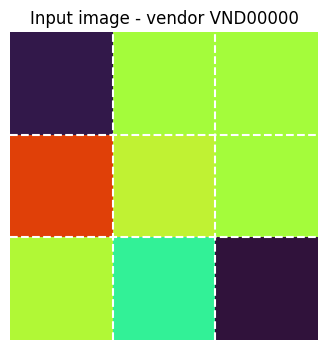

In [19]:
def build_input_image(row, colormap="turbo"):
    normed = normalize_row(row)
    cmap = cm.get_cmap(colormap)

    img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    for (r, c), feat_name in BLOCK_LAYOUT.items():
        val = normed[feat_name]                  # 0-1
        rgba = cmap(val)                          # smooth color from colormap
        rgb = (np.array(rgba[:3]) * 255).astype(np.uint8)

        y0, y1 = r * PATCH_SIZE, (r + 1) * PATCH_SIZE
        x0, x1 = c * PATCH_SIZE, (c + 1) * PATCH_SIZE
        img[y0:y1, x0:x1] = rgb   # solid colored tile

    return img

# Quick test on one vendor
sample_row = features_df.iloc[0]
sample_img = build_input_image(sample_row)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.axvline(15.5, color="white", linewidth=1.5, linestyle="--")
plt.axvline(31.5, color="white", linewidth=1.5, linestyle="--")
plt.axhline(15.5, color="white", linewidth=1.5, linestyle="--")
plt.axhline(31.5, color="white", linewidth=1.5, linestyle="--")
plt.title(f"Input image - vendor {features_df.iloc[0]['vendor_id']}")
plt.axis("off")
plt.show()

In [20]:
# Map each anomaly_type to the block it should "light up"
ANOMALY_TO_BLOCK = {
    "EXPIRED_CERTIFICATION":          (0, 2),   # compliance_certifications
    "BREACHED_VENDOR_HIGH_ACCESS":    (0, 1),   # breach_status
    "RECENTLY_BREACHED_VENDOR":       (0, 1),   # breach_status
    "CONTRACT_EXPIRED_ACTIVE_ACCESS": (1, 0),   # contract_days_left
    "VENDOR_UNDER_INVESTIGATION":     (2, 2),   # audit_to_contract_risk (composite)
    "HIGH_RISK_SCORE":                (0, 0),   # risk_score
    "ELEVATED_RISK_VENDOR":           (0, 0),   # risk_score
    "LOW_RISK_VENDOR":                None,     # no hotspot - normal vendor
}

SEVERITY_WEIGHT = {"low": 0.4, "medium": 0.7, "high": 1.0, "critical": 1.0}

/tmp/ipykernel_482909/265777047.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


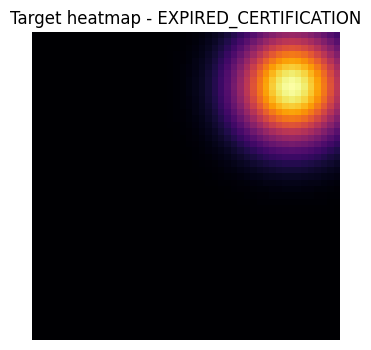

In [21]:
def gaussian_2d(center_y, center_x, sigma, size):
    y, x = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")
    g = np.exp(-((y - center_y) ** 2 + (x - center_x) ** 2) / (2 * sigma ** 2))
    return g

def build_output_heatmap(label_row, colormap="inferno", sigma=6):
    intensity = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    is_anom = label_row["is_anomaly"]
    anomaly_type = label_row.get("anomaly_type", None)
    severity = str(label_row.get("severity", "low")).lower()
    weight = SEVERITY_WEIGHT.get(severity, 0.5)

    if is_anom and anomaly_type in ANOMALY_TO_BLOCK:
        block = ANOMALY_TO_BLOCK[anomaly_type]
        if block is not None:
            r, c = block
            center_y = r * PATCH_SIZE + PATCH_SIZE // 2
            center_x = c * PATCH_SIZE + PATCH_SIZE // 2
            intensity += weight * gaussian_2d(center_y, center_x, sigma, IMG_SIZE)

    # normalize to 0-1, then colorize
    if intensity.max() > 0:
        intensity = intensity / intensity.max()

    cmap = cm.get_cmap(colormap)
    rgba = cmap(intensity)
    heatmap_img = (rgba[:, :, :3] * 255).astype(np.uint8)

    return heatmap_img, intensity

# Quick test - pick a labeled anomalous vendor
sample_label_row = df_label.iloc[0]
hm_img, hm_raw = build_output_heatmap(sample_label_row)

plt.figure(figsize=(4, 4))
plt.imshow(hm_img)
plt.title(f"Target heatmap - {sample_label_row['anomaly_type']}")
plt.axis("off")
plt.show()

In [22]:
merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))
features_df_merged = engineer_features(merged)

X = []
Y = []

for i in range(len(merged)):
    feat_row = features_df_merged.iloc[i]
    label_row = merged.iloc[i]

    x_img = build_input_image(feat_row)
    y_img, y_raw = build_output_heatmap(label_row)

    X.append(x_img)
    Y.append(y_raw)   # store raw intensity (0-1, single channel) for training target

X = np.array(X)            # shape: (N, 48, 48, 3)
Y = np.array(Y)            # shape: (N, 48, 48)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

/tmp/ipykernel_482909/3017914735.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)
/tmp/ipykernel_482909/265777047.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


X shape: (400, 48, 48, 3)
Y shape: (400, 48, 48)


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# X: (N, 48, 48, 3) uint8 -> normalize to 0-1, channels-first for PyTorch
X_norm = X.astype(np.float32) / 255.0
X_norm = np.transpose(X_norm, (0, 3, 1, 2))   # (N, 3, 48, 48)

# Y: (N, 48, 48) already 0-1 float -> add channel dim
Y_norm = Y.astype(np.float32)[:, np.newaxis, :, :]   # (N, 1, 48, 48)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_norm, Y_norm, test_size=0.2, random_state=42
)

class VendorHeatmapDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_ds = VendorHeatmapDataset(X_train, Y_train)
val_ds   = VendorHeatmapDataset(X_val, Y_val)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Using device: cuda
Train: 320 | Val: 80


In [32]:
class HeatmapRegressorSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2))
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.enc3 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.bottleneck = nn.Sequential(nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(0.3))
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(64, 32, 2, stride=2), nn.BatchNorm2d(32), nn.ReLU())
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(32, 16, 2, stride=2), nn.BatchNorm2d(16), nn.ReLU())
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(16, 8, 2, stride=2), nn.BatchNorm2d(8), nn.ReLU())
        self.out_conv = nn.Conv2d(8, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.enc1(x); x = self.enc2(x); x = self.enc3(x)
        x = self.bottleneck(x)
        x = self.dec1(x); x = self.dec2(x); x = self.dec3(x)
        return self.sigmoid(self.out_conv(x))

model = HeatmapRegressorSmall().to(device)
print(sum(p.numel() for p in model.parameters()), "params")

71793 params


In [44]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-1, weight_decay=1e-9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

EPOCHS = 1000
train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    # --- train ---
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_ds)
    train_losses.append(train_loss)

    # --- validate ---
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_running_loss += loss.item() * xb.size(0)

    val_loss = val_running_loss / len(val_ds)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_heatmap_model.pt")

    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1}/{EPOCHS} | train_loss: {train_loss:.5f} | val_loss: {val_loss:.5f} | lr: {current_lr:.2e}")

print(f"\nBest val loss: {best_val_loss:.5f}")

Epoch 1/1000 | train_loss: 0.03159 | val_loss: 0.03970 | lr: 1.00e-01
Epoch 10/1000 | train_loss: 0.02174 | val_loss: 0.02484 | lr: 1.00e-01
Epoch 20/1000 | train_loss: 0.02066 | val_loss: 0.02571 | lr: 5.00e-02
Epoch 30/1000 | train_loss: 0.01993 | val_loss: 0.02510 | lr: 5.00e-02
Epoch 40/1000 | train_loss: 0.01968 | val_loss: 0.02592 | lr: 2.50e-02
Epoch 50/1000 | train_loss: 0.01893 | val_loss: 0.02558 | lr: 1.25e-02
Epoch 60/1000 | train_loss: 0.01859 | val_loss: 0.02714 | lr: 6.25e-03
Epoch 70/1000 | train_loss: 0.01798 | val_loss: 0.02780 | lr: 3.13e-03
Epoch 80/1000 | train_loss: 0.01761 | val_loss: 0.02810 | lr: 3.13e-03
Epoch 90/1000 | train_loss: 0.01744 | val_loss: 0.02806 | lr: 1.56e-03
Epoch 100/1000 | train_loss: 0.01742 | val_loss: 0.02818 | lr: 7.81e-04
Epoch 110/1000 | train_loss: 0.01738 | val_loss: 0.02826 | lr: 3.91e-04
Epoch 120/1000 | train_loss: 0.01720 | val_loss: 0.02823 | lr: 1.95e-04
Epoch 130/1000 | train_loss: 0.01718 | val_loss: 0.02823 | lr: 9.77e-05
Epo

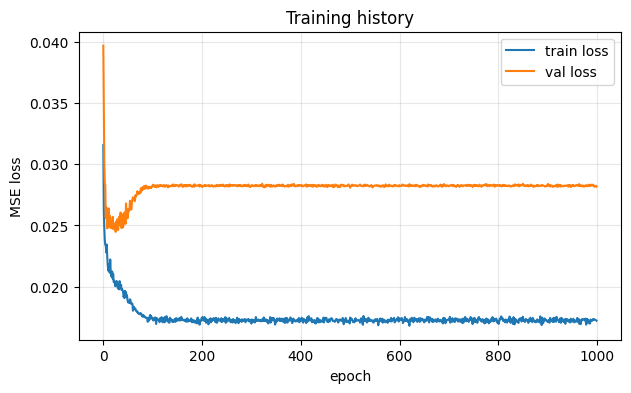

In [45]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Training history")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [46]:
model.eval()
with torch.no_grad():
    all_preds = []
    for xb, yb in val_loader:
        preds = model(xb.to(device)).cpu().numpy()
        all_preds.append(preds)
    all_preds = np.concatenate(all_preds, axis=0)

print("Pred variance across samples:", all_preds.var())
print("Pred mean:", all_preds.mean())
print("True mean:", Y_val.mean())

Pred variance across samples: 0.012200271
Pred mean: 0.05657284
True mean: 0.07108068


In [47]:
def get_hot_block(heatmap_2d):
    """Find which of the 9 blocks has the highest average intensity"""
    block_scores = {}
    for (r, c) in BLOCK_LAYOUT.keys():
        y0, y1 = r * PATCH_SIZE, (r + 1) * PATCH_SIZE
        x0, x1 = c * PATCH_SIZE, (c + 1) * PATCH_SIZE
        block_scores[(r, c)] = heatmap_2d[y0:y1, x0:x1].mean()
    return max(block_scores, key=block_scores.get)

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for xb, yb in val_loader:
        preds = model(xb.to(device)).cpu().numpy()
        yb_np = yb.numpy()
        for i in range(len(xb)):
            true_block = get_hot_block(yb_np[i, 0])
            pred_block = get_hot_block(preds[i, 0])
            if true_block == pred_block:
                correct += 1
            total += 1

print(f"Block-level hotspot accuracy: {correct}/{total} = {correct/total:.2%}")

Block-level hotspot accuracy: 36/80 = 45.00%


In [48]:
from collections import Counter

true_blocks_val = []
with torch.no_grad():
    for xb, yb in val_loader:
        yb_np = yb.numpy()
        for i in range(len(xb)):
            true_blocks_val.append(get_hot_block(yb_np[i, 0]))

block_counts = Counter(true_blocks_val)
print("True block distribution in val set:")
for block, count in block_counts.most_common():
    print(f"  {block} ({BLOCK_LAYOUT[block]}): {count} ({count/len(true_blocks_val):.1%})")

majority_baseline = block_counts.most_common(1)[0][1] / len(true_blocks_val)
print(f"\nMajority-class baseline accuracy: {majority_baseline:.2%}")

True block distribution in val set:
  (0, 0) (risk_score): 30 (37.5%)
  (0, 2) (compliance_certifications): 27 (33.8%)
  (0, 1) (breach_status): 14 (17.5%)
  (2, 2) (audit_to_contract_risk): 7 (8.8%)
  (1, 0) (contract_days_left): 2 (2.5%)

Majority-class baseline accuracy: 37.50%


In [49]:
import pandas as pd

pred_blocks_val = []
with torch.no_grad():
    for xb, yb in val_loader:
        preds = model(xb.to(device)).cpu().numpy()
        for i in range(len(xb)):
            pred_blocks_val.append(get_hot_block(preds[i, 0]))

confusion = pd.crosstab(
    pd.Series([BLOCK_LAYOUT[b] for b in true_blocks_val], name="True"),
    pd.Series([BLOCK_LAYOUT[b] for b in pred_blocks_val], name="Predicted")
)
print(confusion)

Predicted                  breach_status  compliance_certifications  \
True                                                                  
audit_to_contract_risk                 0                          4   
breach_status                          0                         14   
compliance_certifications              2                         24   
contract_days_left                     0                          2   
risk_score                             2                         16   

Predicted                  risk_score  
True                                   
audit_to_contract_risk              3  
breach_status                       0  
compliance_certifications           1  
contract_days_left                  0  
risk_score                         12  


Normal-only training samples: 78
Full dataset (for scoring): 400
Params: 131,027
Params: 131,027
Params: 131,027
Params: 131,027
Epoch 1/300 | train: 0.11021 | val: 0.11327
Epoch 10/300 | train: 0.05416 | val: 0.05384
Epoch 20/300 | train: 0.03071 | val: 0.03003
Epoch 30/300 | train: 0.01594 | val: 0.01494
Epoch 40/300 | train: 0.00663 | val: 0.00570
Epoch 50/300 | train: 0.00326 | val: 0.00236
Epoch 60/300 | train: 0.00222 | val: 0.00146
Epoch 70/300 | train: 0.00171 | val: 0.00116
Epoch 80/300 | train: 0.00156 | val: 0.00086
Epoch 90/300 | train: 0.00125 | val: 0.00078
Epoch 100/300 | train: 0.00111 | val: 0.00062
Epoch 110/300 | train: 0.00116 | val: 0.00060
Epoch 120/300 | train: 0.00080 | val: 0.00051
Epoch 130/300 | train: 0.00109 | val: 0.00049
Epoch 140/300 | train: 0.00071 | val: 0.00051
Epoch 150/300 | train: 0.00065 | val: 0.00041
Epoch 160/300 | train: 0.00073 | val: 0.00041
Epoch 170/300 | train: 0.00060 | val: 0.00039
Epoch 180/300 | train: 0.00080 | val: 0.00039
Epoch 19

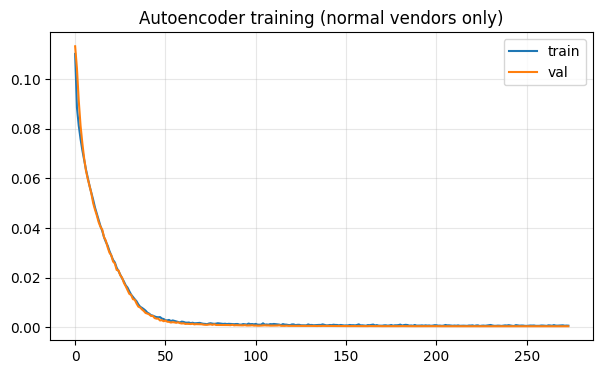

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- 1. Reuse your existing 48x48x3 input images (X from earlier) ----
X_norm = X.astype(np.float32) / 255.0
X_norm = np.transpose(X_norm, (0, 3, 1, 2))   # (N, 3, 48, 48)

# Important: train the autoencoder ONLY on vendors labeled "normal" (is_anomaly == False)
# so it learns what a clean vendor profile looks like, and anomalies show up as high error later.
is_anom_array = merged["is_anomaly"].values
X_normal = X_norm[~is_anom_array]
X_all = X_norm   # full set, used later for inference/error scoring

print(f"Normal-only training samples: {X_normal.shape[0]}")
print(f"Full dataset (for scoring): {X_all.shape[0]}")

X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

class ImageOnlyDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

train_loader = DataLoader(ImageOnlyDataset(X_train), batch_size=8, shuffle=True)
val_loader   = DataLoader(ImageOnlyDataset(X_val), batch_size=8, shuffle=False)

# ---- 2. True autoencoder: input == output, same shape, same channels ----
class ConvAutoencoderTightBottleneck(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)   # 48 -> 24

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)   # 24 -> 12

        self.enc3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU()
        )
        self.pool3 = nn.MaxPool2d(2)   # 12 -> 6

        # ---- NEW: extra compression stage, narrower channels ----
        self.enc4 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU()
        )
        self.pool4 = nn.MaxPool2d(3)   # 6 -> 2   (tight bottleneck: 2x2x32 = 128 dims, vs old 6x6x64=2304)

        # ---- Decoder ----
        self.up0 = nn.ConvTranspose2d(32, 64, 3, stride=3)   # 2 -> 6 (undo pool4, no skip here - true bottleneck)

        self.up1 = nn.ConvTranspose2d(64, 64, 2, stride=2)   # 6 -> 12
        self.dec1 = nn.Sequential(
            nn.Conv2d(64 + 64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU()  # +skip from e3 (12x12, 64ch)
        )

        self.up2 = nn.ConvTranspose2d(32, 32, 2, stride=2)   # 12 -> 24
        self.dec2 = nn.Sequential(
            nn.Conv2d(32 + 32, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU()  # +skip from e2 (24x24, 32ch)
        )

        self.up3 = nn.ConvTranspose2d(16, 16, 2, stride=2)   # 24 -> 48
        self.dec3 = nn.Sequential(
            nn.Conv2d(16 + 16, 8, 3, padding=1), nn.BatchNorm2d(8), nn.ReLU()    # +skip from e1 (48x48, 16ch)
        )

        self.out_conv = nn.Conv2d(8, 3, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x)        # (16, 48, 48)
        p1 = self.pool1(e1)      # (16, 24, 24)

        e2 = self.enc2(p1)       # (32, 24, 24)
        p2 = self.pool2(e2)      # (32, 12, 12)

        e3 = self.enc3(p2)       # (64, 12, 12)
        p3 = self.pool3(e3)      # (64, 6, 6)

        e4 = self.enc4(p3)       # (32, 6, 6)
        p4 = self.pool4(e4)      # (32, 2, 2)   <-- bottleneck, no skip connection here on purpose

        d0 = self.up0(p4)        # (64, 6, 6) - back up from the tight bottleneck

        d1 = self.up1(d0)                  # (64, 12, 12)
        d1 = torch.cat([d1, e3], dim=1)    # concat with e3 -> (128, 12, 12)
        d1 = self.dec1(d1)                 # -> (32, 12, 12)

        d2 = self.up2(d1)                  # (32, 24, 24)
        d2 = torch.cat([d2, e2], dim=1)    # concat with e2 -> (64, 24, 24)
        d2 = self.dec2(d2)                 # -> (16, 24, 24)

        d3 = self.up3(d2)                  # (16, 48, 48)
        d3 = torch.cat([d3, e1], dim=1)    # concat with e1 -> (32, 48, 48)
        d3 = self.dec3(d3)                 # -> (8, 48, 48)

        out = self.out_conv(d3)
        out = self.sigmoid(out)
        return out

model = ConvAutoencoderTightBottleneck().to(device)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

model = ConvAutoencoderTightBottleneck().to(device)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

# ---- 3. Train: reconstruct normal vendors only ----
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

EPOCHS = 300
best_val_loss = float("inf")
patience, patience_counter = 20, 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for xb in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        recon = model(xb)
        loss = criterion(recon, xb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb in val_loader:
            xb = xb.to(device)
            recon = model(xb)
            loss = criterion(recon, xb)
            val_running_loss += loss.item() * xb.size(0)
    val_loss = val_running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_autoencoder.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | train: {train_loss:.5f} | val: {val_loss:.5f}")

print(f"\nBest val loss (normal vendors only): {best_val_loss:.5f}")

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend(); plt.grid(alpha=0.3)
plt.title("Autoencoder training (normal vendors only)")
plt.show()

In [60]:
# ---- 4. Score ALL vendors (normal + anomalous) by reconstruction error ----
model.load_state_dict(torch.load("best_autoencoder.pt"))
model.eval()

X_all_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)

with torch.no_grad():
    recon_all = model(X_all_tensor).cpu().numpy()

# Per-vendor scalar error (mean squared error across whole image)
errors_per_vendor = ((X_all - recon_all) ** 2).mean(axis=(1, 2, 3))

# Per-vendor, per-block error map (this is your explainability heatmap)
def per_block_error(x_img, recon_img):
    """x_img, recon_img: (3, 48, 48). Returns dict block -> error"""
    block_err = {}
    for (r, c), feat_name in BLOCK_LAYOUT.items():
        y0, y1 = r * PATCH_SIZE, (r + 1) * PATCH_SIZE
        x0, x1 = c * PATCH_SIZE, (c + 1) * PATCH_SIZE
        diff = (x_img[:, y0:y1, x0:x1] - recon_img[:, y0:y1, x0:x1]) ** 2
        block_err[feat_name] = diff.mean()
    return block_err

results = []
for i in range(len(X_all)):
    block_errs = per_block_error(X_all[i], recon_all[i])
    top_feature = max(block_errs, key=block_errs.get)
    results.append({
        "vendor_id": merged.iloc[i]["vendor_id"],
        "is_anomaly_true": merged.iloc[i]["is_anomaly"],
        "anomaly_type_true": merged.iloc[i]["anomaly_type"],
        "reconstruction_error": errors_per_vendor[i],
        "top_error_feature": top_feature,
        **{f"err_{k}": v for k, v in block_errs.items()}
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("reconstruction_error", ascending=False)
results_df.head(20)

,vendor_id,is_anomaly_true,anomaly_type_true,reconstruction_error,top_error_feature,err_risk_score,err_breach_status,err_compliance_certifications,err_contract_days_left,err_annual_spend,err_data_access_scope,err_audit_days_since,err_vendor_type,err_audit_to_contract_risk
88,VND00088,True,HIGH_RISK_SCORE,0.000831,risk_score,0.001803,0.000212,0.000198,0.000212,0.000081,0.000217,0.001638,0.001385,0.001729
251,VND00251,True,EXPIRED_CERTIFICATION,0.000815,audit_to_contract_risk,0.001454,0.000230,0.000200,0.000288,0.000647,0.000219,0.001385,0.000229,0.002680
180,VND00180,True,EXPIRED_CERTIFICATION,0.000789,audit_to_contract_risk,0.001629,0.000224,0.000200,0.000286,0.001133,0.000239,0.001475,0.000162,0.001756
70,VND00070,True,CONTRACT_EXPIRED_ACTIVE_ACCESS,0.000742,audit_to_contract_risk,0.000173,0.000228,0.000199,0.000284,0.001627,0.000223,0.001700,0.000409,0.001838
76,VND00076,True,RECENTLY_BREACHED_VENDOR,0.000741,audit_days_since,0.001316,0.000219,0.000200,0.000271,0.001417,0.000201,0.001617,0.001353,0.000074
223,VND00223,True,VENDOR_UNDER_INVESTIGATION,0.000717,risk_score,0.001961,0.000221,0.000199,0.000506,0.001593,0.000215,0.001454,0.000175,0.000127
74,VND00074,True,RECENTLY_BREACHED_VENDOR,0.000710,audit_to_contract_risk,0.001633,0.000222,0.000198,0.000268,0.000094,0.000211,0.000117,0.001481,0.002168
132,VND00132,True,VENDOR_UNDER_INVESTIGATION,0.000706,risk_score,0.001715,0.000240,0.000198,0.000298,0.000357,0.000218,0.001174,0.000716,0.001443
298,VND00298,True,EXPIRED_CERTIFICATION,0.000688,audit_to_contract_risk,0.001606,0.000215,0.000199,0.000171,0.000384,0.000207,0.000297,0.001437,0.001677
219,VND00219,True,HIGH_RISK_SCORE,0.000679,risk_score,0.001905,0.000227,0.000199,0.000354,0.000952,0.000217,0.000420,0.001172,0.000669


                 count      mean       std       min       25%       50%  \
is_anomaly_true                                                            
False             78.0  0.000307  0.000108  0.000123  0.000227  0.000298   
True             322.0  0.000392  0.000137  0.000139  0.000292  0.000375   

                      75%       max  
is_anomaly_true                      
False            0.000367  0.000582  
True             0.000470  0.000831  


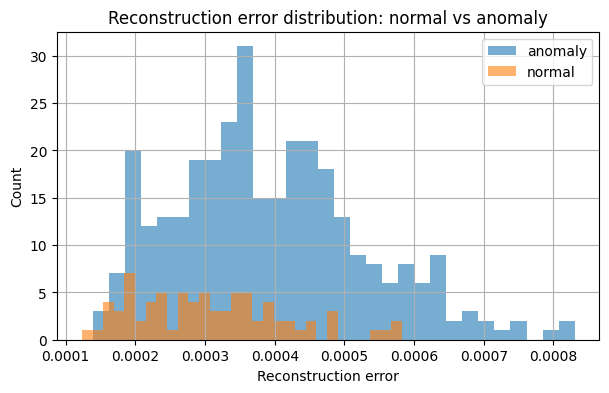

top_error_feature               annual_spend  audit_days_since  \
anomaly_type_true                                                
BREACHED_VENDOR_HIGH_ACCESS               10                 5   
CONTRACT_EXPIRED_ACTIVE_ACCESS             0                 0   
ELEVATED_RISK_VENDOR                       1                 6   
EXPIRED_CERTIFICATION                     29                26   
HIGH_RISK_SCORE                            4                 3   
LOW_RISK_VENDOR                           11                24   
RECENTLY_BREACHED_VENDOR                   6                 9   
VENDOR_UNDER_INVESTIGATION                 4                 1   

top_error_feature               audit_to_contract_risk  breach_status  \
anomaly_type_true                                                       
BREACHED_VENDOR_HIGH_ACCESS                          0              0   
CONTRACT_EXPIRED_ACTIVE_ACCESS                       3              0   
ELEVATED_RISK_VENDOR                           

In [61]:
# ---- 5. Validate: do anomalies actually get higher reconstruction error? ----
print(results_df.groupby("is_anomaly_true")["reconstruction_error"].describe())

plt.figure(figsize=(7, 4))
results_df[results_df["is_anomaly_true"]]["reconstruction_error"].hist(bins=30, alpha=0.6, label="anomaly")
results_df[~results_df["is_anomaly_true"]]["reconstruction_error"].hist(bins=30, alpha=0.6, label="normal")
plt.xlabel("Reconstruction error")
plt.ylabel("Count")
plt.legend()
plt.title("Reconstruction error distribution: normal vs anomaly")
plt.show()

# Does top_error_feature align with the known anomaly cause?
print(pd.crosstab(results_df["anomaly_type_true"], results_df["top_error_feature"]))

ROC-AUC (reconstruction error as anomaly score): 0.683


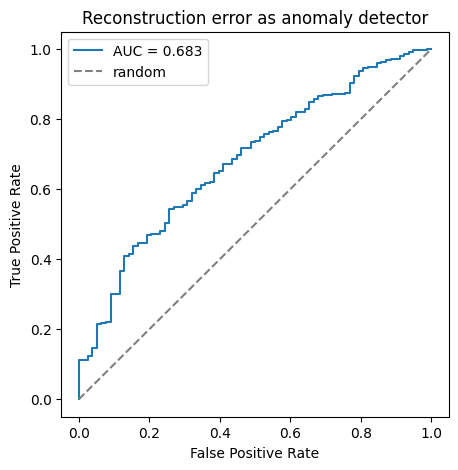

In [62]:
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(results_df["is_anomaly_true"], results_df["reconstruction_error"])
print(f"ROC-AUC (reconstruction error as anomaly score): {auc:.3f}")

fpr, tpr, thresholds = roc_curve(results_df["is_anomaly_true"], results_df["reconstruction_error"])
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Reconstruction error as anomaly detector")
plt.legend()
plt.show()